In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import math
import pandas as pd

#plt.rcParams['text.usetex'] = True

from utils import *

from scipy.optimize import curve_fit

## Model definition

In [2]:
N = 4

A = 0.3

h = 0.36

dt = 0.01
Nt = 500

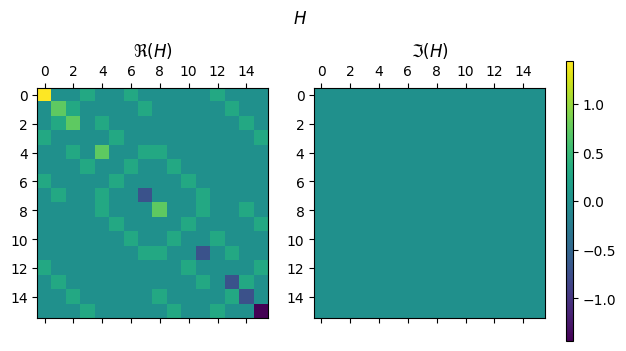

In [3]:
H = np.zeros([2**N,2**N])
for j in range(N-1):
    H = H + u_ith(X(),j,N)@u_ith(X(),j+1,N)*A
for j in range(N):
    H = H + u_ith(Z(),j,N)*h

plot_matrix(H,'H')

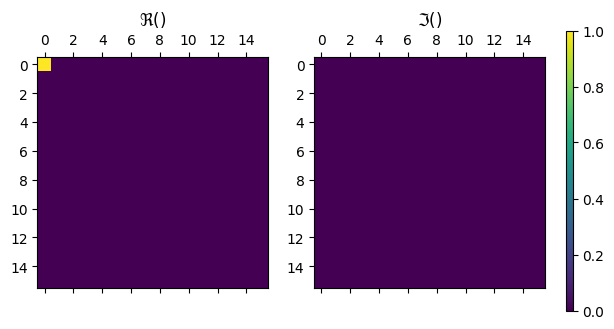

In [4]:
p = (np.random.rand(2**N))
rho_0 = np.diag(p/np.sum(p))
rho_0 = ketbra(0,0,2**N)
plot_matrix(rho_0)

## Simulation

In [5]:
ts = np.arange(Nt+1)*dt

In [6]:
C=[]
for j in range(N):
    C.append(np.diag(u_ith(Z(),j,N)))
C = np.array(C)

## Original model

In [7]:
def output(rho):
    return np.real(np.diag(rho))

Lvec = Lindblad_to_matrix(np.real(H),[])

x_0 = vec(rho_0)
    
A = sp.linalg.expm(Lvec*dt)

x_t = x_0

out = [output(unvec(x_t))]

for j in range(Nt):
    x_t = A@x_t
    out.append(output(unvec(x_t)))

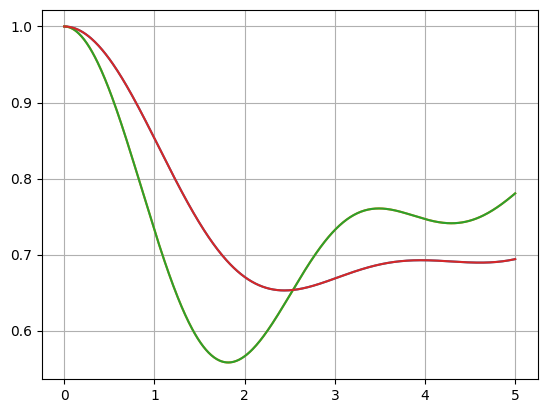

In [8]:
out = np.array(out)
ys = (C@out.T).T
plt.figure()
plt.plot(ts,ys)
plt.grid()
plt.show()

data = np.array([ts,ys[:,0]])
header = ['t','z'] 
df = pd.DataFrame(data.T, columns=header)
df.to_csv('../data/traj_spin_chain_exact.csv',index=False)

## Reduced model

In [9]:
R = []
for j in range(2**N):
    R.append(vec(ketbra(j,j,2**N)))
R = np.array(R).reshape([2**N,4**N])
J = R.H

print(R.shape)


(16, 256)


In [10]:
m = 2**N

def get_Fs(L,J,R,order):
    Fs = [np.zeros([m,m])]

    for k in range(1,order+1):
        F = R@np.linalg.matrix_power(L,k)@J /math.factorial(k-1)
        C = np.zeros_like(F)
        for h in range(1,k):
            C += Fs[k-h]@R@np.linalg.matrix_power(L,h)@J /math.factorial(h)
        Fs.append(np.real(F - C))
    return Fs

def get_Es(Fs, M_max=50):
    Es = [np.eye(m)]
    for k in range(1,M_max):
        E = np.zeros([m,m], dtype=np.float64)
        for s in range(1,k+1):
            if s< len(Fs):
                E = E + Fs[s]@Es[k-s]/k
        Es.append(E)
    return Es

Fs = get_Fs(Lvec,J,R,20)
Es = get_Es(Fs, M_max=60)

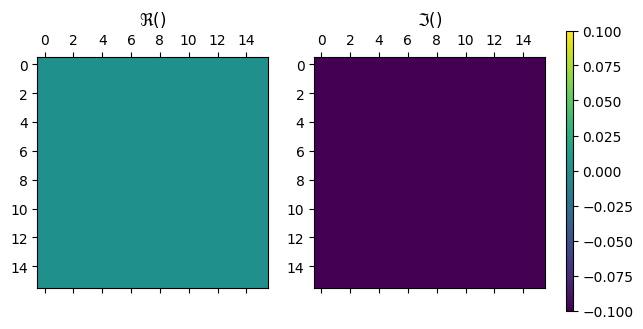

True


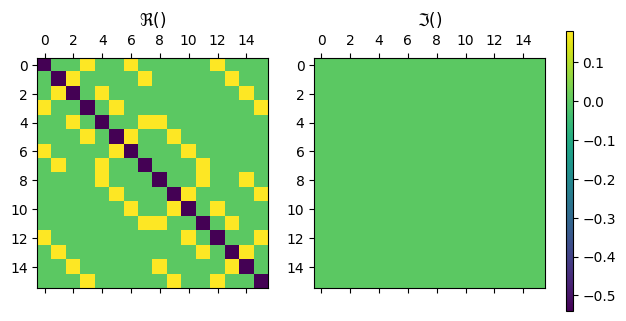

True
-0.5399999999999999 0.18


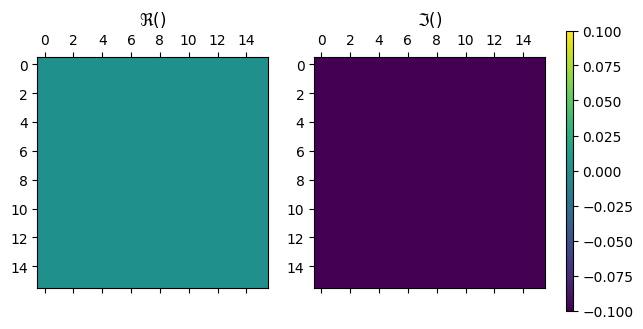

True


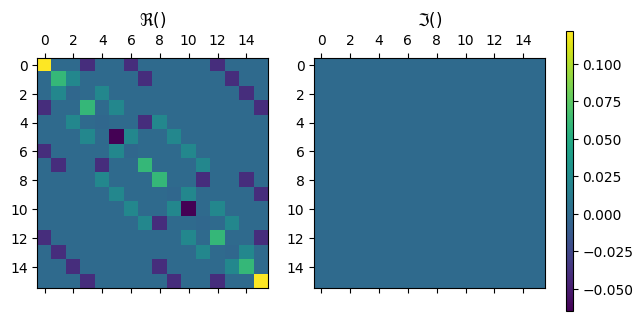

False


In [11]:
def is_metzler_stochastic(A):
    X = np.real(A) 
    X = X - 2*np.eye(X.shape[0])*np.min(X)
    return np.all(X>=0) and np.all(np.round(np.sum(A,axis=1),decimals=12)==0)

plot_matrix(Fs[1])
print(is_metzler_stochastic(Fs[1]))
plot_matrix(Fs[2])
print(is_metzler_stochastic(Fs[2]))
print(np.min(Fs[2]), np.max(Fs[2]))
plot_matrix(Fs[3])
print(is_metzler_stochastic(Fs[3]))
plot_matrix(Fs[4])
print(is_metzler_stochastic(Fs[4]))

In [12]:
dim = Fs[2].shape[0]
row_ind = np.arange(0,dim,1)*np.ones([dim,dim])
col_ind = row_ind.T

data = np.array([row_ind.reshape([dim**2,]), 
                 col_ind.reshape([dim**2,]),
                 Fs[2].reshape([dim**2,])])

header = ['i','j','v'] 
df = pd.DataFrame(data.T, columns=header)
print(df)
df.to_csv('../data/matrix.csv',index=False, sep=' ')

        i     j     v
0     0.0   0.0 -0.54
1     1.0   0.0  0.00
2     2.0   0.0  0.00
3     3.0   0.0  0.18
4     4.0   0.0  0.00
..    ...   ...   ...
251  11.0  15.0  0.00
252  12.0  15.0  0.18
253  13.0  15.0  0.00
254  14.0  15.0  0.00
255  15.0  15.0 -0.54

[256 rows x 3 columns]


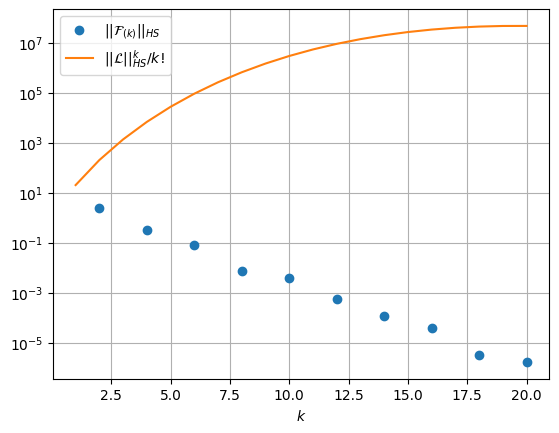

In [13]:
ks = np.arange(len(Fs))

def NORM(X):
    X = np.matrix(X)
    return np.real(np.sqrt(np.trace(X.H@X)))

norms_F = []
for F in Fs:
    norms_F.append(NORM(F))

theoretical = [0]
for k in ks[1:]:
    theoretical.append(NORM(Lvec)**k/math.factorial(k))

plt.figure()
plt.plot(ks[1:],norms_F[1:],'o',label=r'$||\mathcal{F}_{(k)}||_{HS}$')
plt.plot(ks[1:],theoretical[1:],label=r'$||\mathcal{L}||_{HS}^k/k!$')
plt.yscale('log')
plt.grid()
plt.legend()
plt.xlabel(r'$k$')
plt.show()

In [14]:
Ns = [2,4, 10, 20]

data = [ts]
fit = []
output = []
for order in Ns:
    Es = get_Es(Fs[:order+1], M_max=100)

    xcm_0 = R@vec(rho_0)

    es = []
    for E in Es:
        es.append(E@xcm_0)

    ys_mc = []
    for t in ts:
        xcm_t = np.zeros_like(xcm_0)
        for k,e in enumerate(es):
            xcm_t = xcm_t + e*(t**k)
        ys_mc.append(np.real(xcm_t))

    ys_mc = np.array(ys_mc).reshape([Nt+1,2**N])

    output.append(ys_mc)

[0.02562] [[5.79826e-08]]
[0.00317] [[1.1414e-10]]
[5.72075e-06] [[3.13415e-16]]
[2.71249e-09] [[4.7618e-24]]


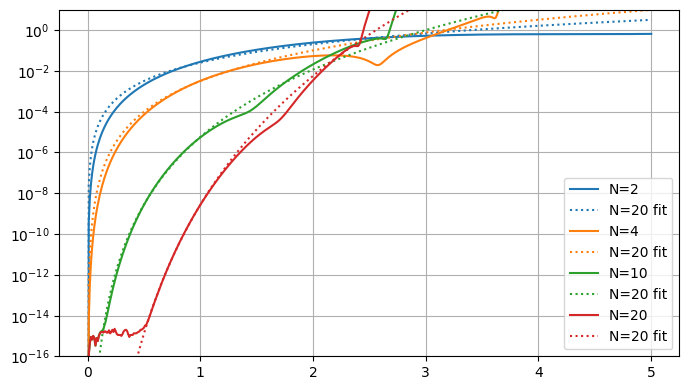

In [15]:
def distance(rho,tau):
    A = rho-tau
    return np.linalg.norm(A)

data=[ts]
fit=[]
plt.figure(figsize=(16/2,9/2))
for j, out_mc in enumerate(output):
    error = []
    for k in range(out.shape[0]):
        error.append(distance(out[k,:],out_mc[k,:]))

    data.append(error)
    lines = plt.plot(ts,error,'-',label='N='+str(Ns[j]))
    def func(x, a):
         return a * x**(Ns[j]+1)

    popt, pcov = curve_fit(func, ts[:100], error[:100])
    print(popt, pcov)
    linecolor = lines[0].get_color()
    plt.plot(ts,func(ts,popt),':',label='N='+str(order)+' fit', color=linecolor)
    fit.append(func(ts,popt))

plt.grid()
plt.yscale('log')
plt.ylim([1e-16,10])
plt.legend()
plt.show()

header = ['t']+['n'+str(k) for k in Ns] +['f'+str(k) for k in Ns] 
df = pd.DataFrame(np.concatenate((np.array(data),np.array(fit))).T, columns=header)
df.to_csv('../data/errors_spin_chain.csv',index=False)

In [16]:
inds=[]
for j, out_mc in enumerate(output):
    c1 = np.round(np.sum(out_mc,axis=1), decimals=10)!=1
    c2 = np.max(out_mc,axis=1)>1
    c3 = np.min(out_mc,axis=1)<0
    cc = np.logical_or(np.logical_or(c1,c2),c3)
    err = np.where(cc)[0]
    if len(err)>0:
        ind = err[0]-1
    else:
        ind = Nt
    inds.append(ind)

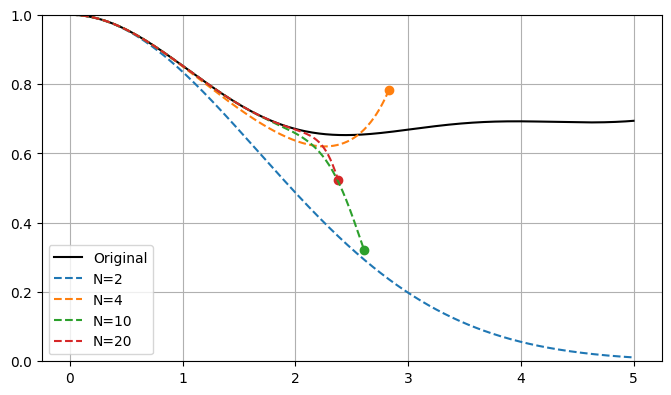

In [17]:
plt.figure(figsize=(16/2,9/2))
plt.plot(ts,ys[:,0],'k',label='Original')
final_points = []
for j, out_mc in enumerate(output):
    ys_mc = np.real(C@out_mc.T).T
    lines = plt.plot(ts[:inds[j]+1],ys_mc[:inds[j]+1,0],'--',label='N='+str(Ns[j]))
    if inds[j]<Nt:
        linecolor = lines[0].get_color()
        plt.scatter(ts[inds[j]],ys_mc[inds[j],0], color=linecolor)
        final_points.append([ts[inds[j]],ys_mc[inds[j],0]])

    data = np.array([ts[:inds[j]+1],ys_mc[:inds[j]+1,0]])
    header = ['t','z'] 
    df = pd.DataFrame(data.T, columns=header)
    df.to_csv('../data/traj_spin_chain'+str(Ns[j])+'.csv',index=False)

df = pd.DataFrame(np.array(final_points), columns=header)    
df.to_csv('../data/spin_chain_final_points.csv',index=False)

plt.grid()
#plt.yscale('log')
M = 1.5*np.max(np.abs(ys[:,0]))
plt.ylim([0,1])

plt.legend()
plt.show()

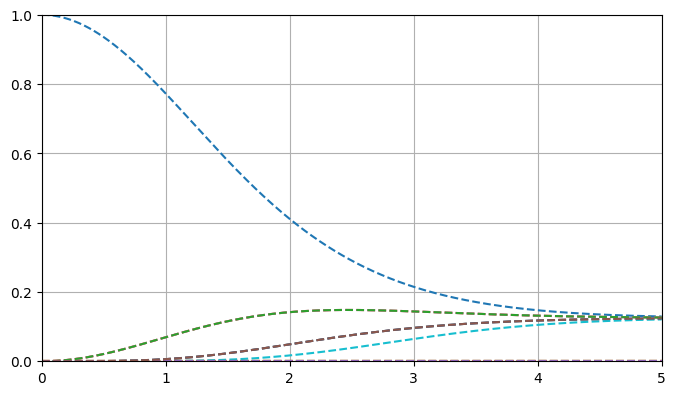

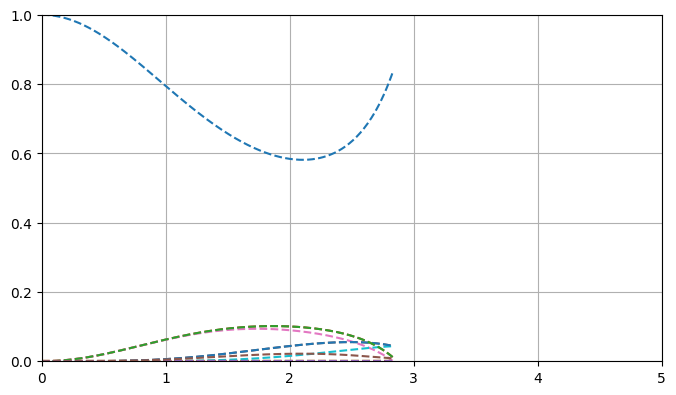

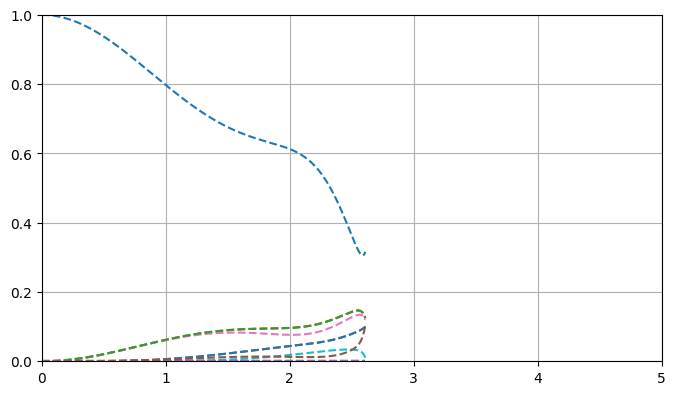

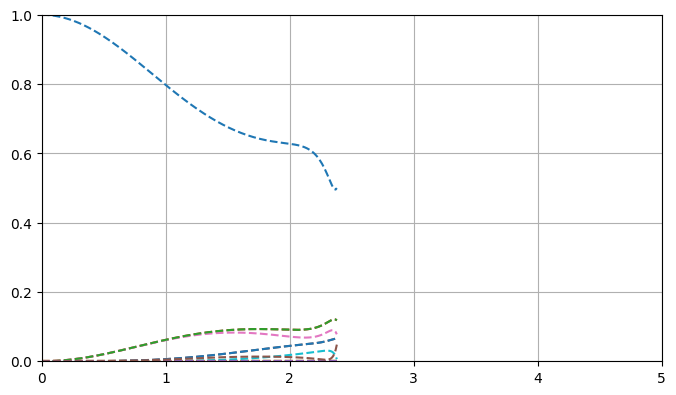

In [18]:

for j, out_mc in enumerate(output):
    ys_mc = np.real(C@out_mc.T).T
    plt.figure(figsize=(16/2,9/2))
    lines = plt.plot(ts[:inds[j]+1],out_mc[:inds[j]+1],'--',label='N='+str(Ns[j]))
    plt.grid()
    plt.ylim([0,1])
    plt.xlim([0,5])
    plt.show()

